In this notebook, we expand on the partial derivative calculus of the *Single Point Regression Gradient* notebook to: 

* Calculate the gradient of mean squared error on a batch of data
* Visualize gradient descent in action

In [2]:
import torch
import matplotlib.pyplot as plt

In [4]:
xs = torch.tensor([0,1,2,3,4,5,6,7])

In [5]:
ys = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])

In [47]:
m = torch.tensor([0.9],requires_grad=True)
b = torch.tensor([0.1],requires_grad=True)

In [48]:
def regression(x,m,b):
    return m*x +b

**Step 1**: Forward pass

In [49]:
yhats = regression(xs,m,b)
yhats

tensor([0.1000, 1.0000, 1.9000, 2.8000, 3.7000, 4.6000, 5.5000, 6.4000],
       grad_fn=<AddBackward0>)

**Step 2:** Compare $yhats$ and $y$ (MSE)

let's use mean squared error, which averages quadratic cost across multiple data points: $$C = \frac{1}{n} \sum_{i=1}^n (\hat{y_i}-y_i)^2 $$

In [50]:
def mse(yhat,y):
    sigma= torch.sum(torch.square(yhat-y))
    return sigma/len(y)

In [51]:
C = mse(yhats,ys)
C

tensor(19.6755, grad_fn=<DivBackward0>)

**Step 3:** Calculate Gradient

In [52]:
C.backward()

In [56]:
m.grad #partial derivative w.r.t m

tensor([36.3050])

In [55]:
b.grad #partial derivative w.r.t b

tensor([6.2650])

In [60]:
gradient = torch.tensor([[b.grad.item(),m.grad.item()]]).T
gradient

tensor([[ 6.2650],
        [36.3050]])

### Let's see gradient descent in action:

In [69]:
def labeled_regression_plot(x,y,m,b,C,include_grad=True):
    title = 'Cost = {}'.format('%.3g' % C.item())
    if include_grad:
        xlabel = 'm = {}, m grad = {}'.format('%.3g' % m.item(), '%.3g' % m.grad.item())
        ylabel = 'b = {}, b grad = {}'.format('%.3g' % b.item(), '%.3g' % b.grad.item())
    else:
        xlabel = 'm = {}'.format('%.3g' % m.item())
        ylabel = 'b = {}'.format('%.3g' % b.item())

    fig, ax = plt.subplots()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    ax.scatter(x,y)
    m = m.detach().item()
    b = b.detach().item()  
    
    x_min, x_max = ax.get_xlim()
    y_min = regression(x_min, m, b)
    y_max = regression(x_max, m, b)

    ax.set_xlim([x_min, x_max])
    _ = ax.plot([x_min, x_max], [y_min, y_max])

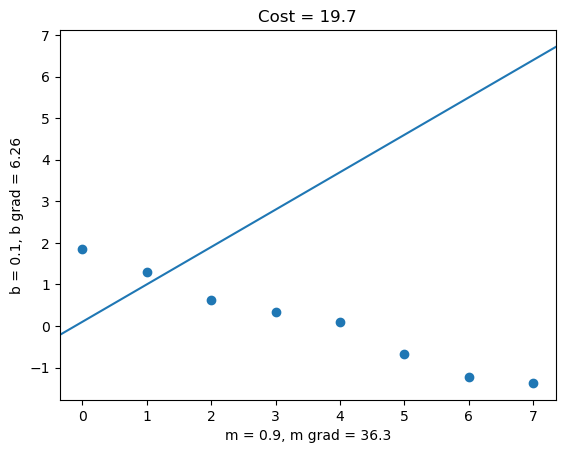

In [70]:
labeled_regression_plot(xs,ys,m,b,C)

**Step 4:** Optimize the Regression line

In [73]:
optimizer = torch.optim.SGD([m,b], lr=0.01)

In [74]:
optimizer.step()

#### From here we will start again from Step 1 upto step 4 untill we fit regression line

**Step 1:** Forward pass

In [75]:
yhat = regression(xs,m,b)

**Step 2:** Mean Squared Error (Comparing yhat and y)

In [77]:
C = mse(yhat,ys)
C

tensor(8.5722, grad_fn=<DivBackward0>)

**Step 3:** Calculate Gradient

In [78]:
C.backward()

In [79]:
m.grad

tensor([59.4647])

In [80]:
b.grad

tensor([9.8633])

##### Lets plot it again to see how much line get fit 

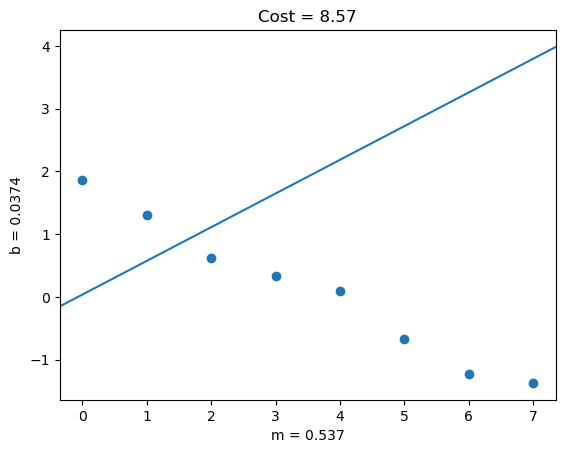

In [84]:
labeled_regression_plot(xs,ys,m,b,C,include_grad=False)

#### So it seems like line is not going to fit we need some serious optimization(Gradient Descendent)
So we can use Epoch technique in order to optimize the regression line

/var/folders/hg/nygj3yv11n768xw3__t2m9p00000gn/T/ipykernel_12431/3816502601.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


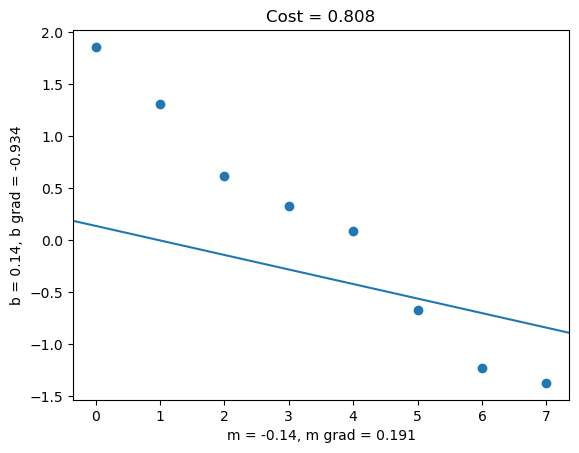

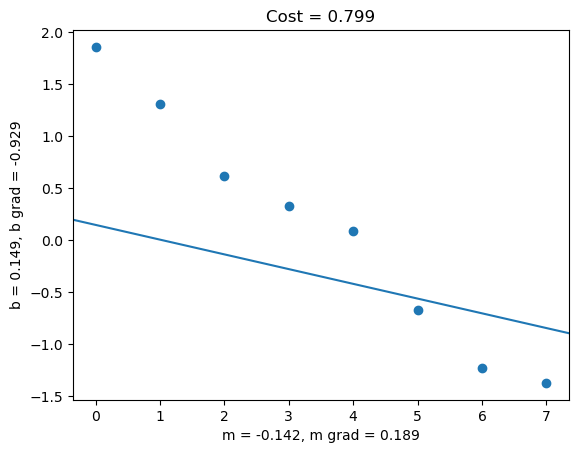

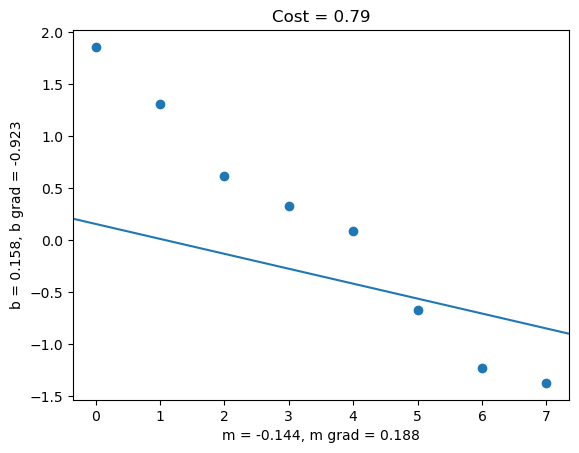

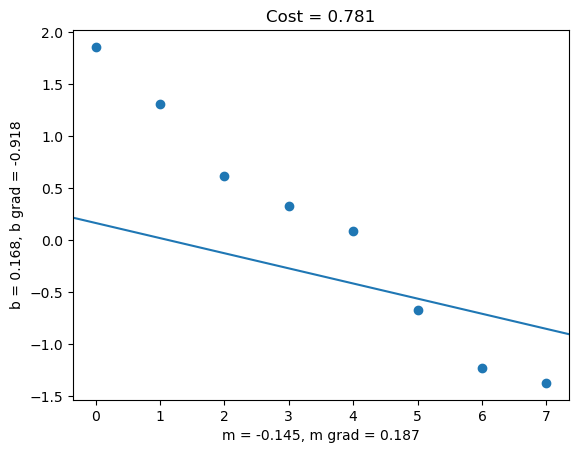

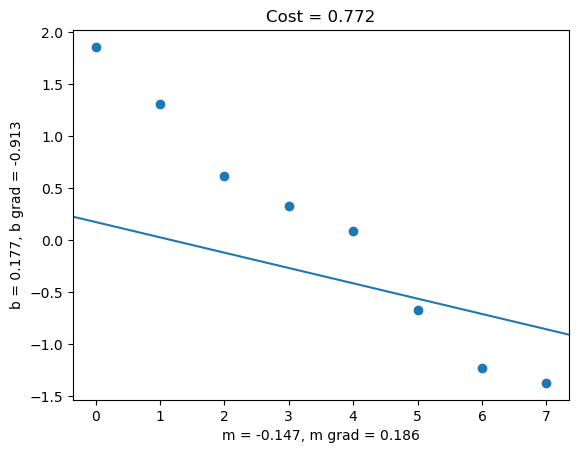

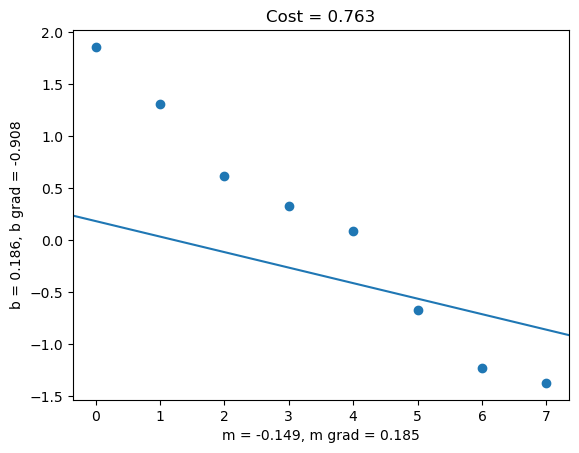

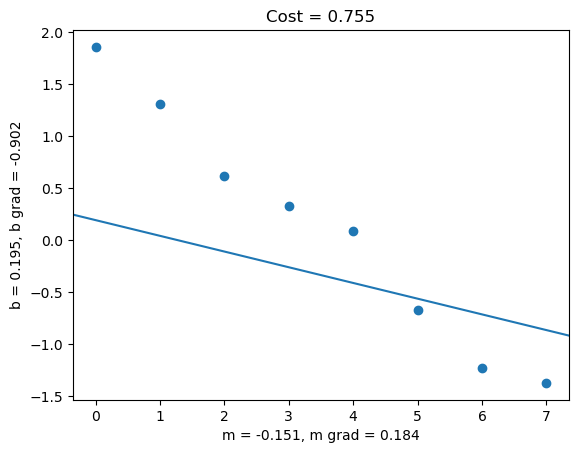

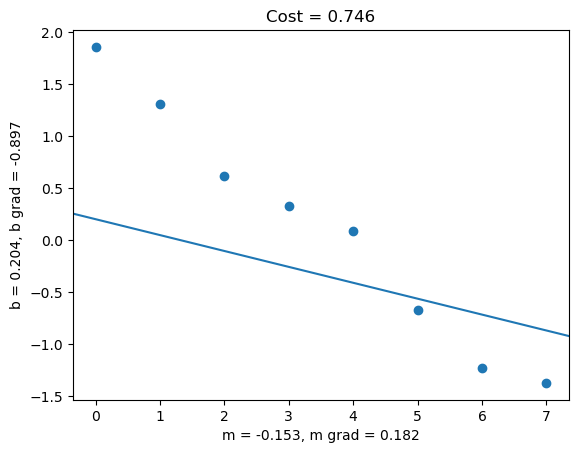

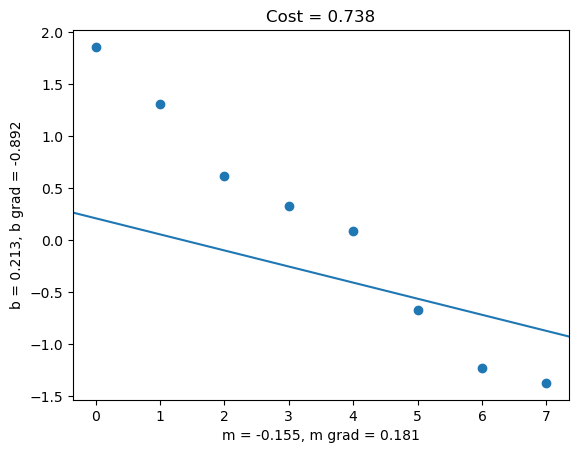

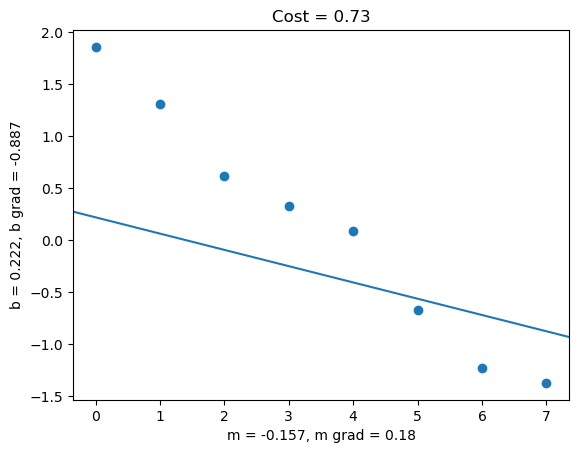

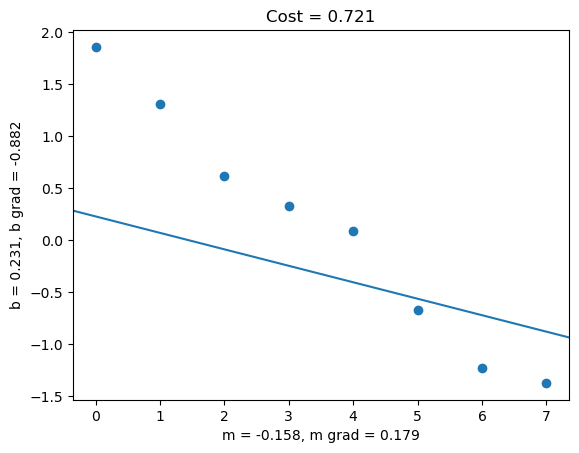

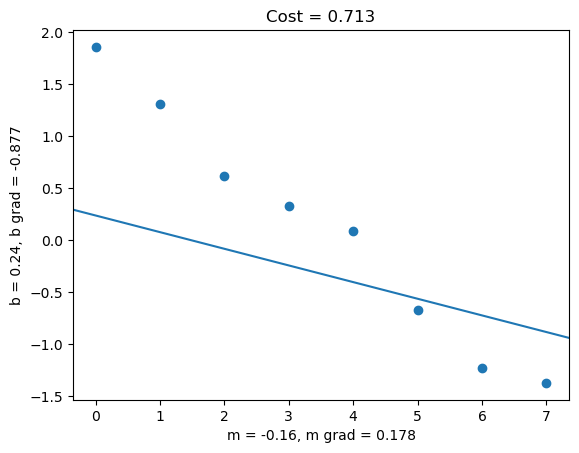

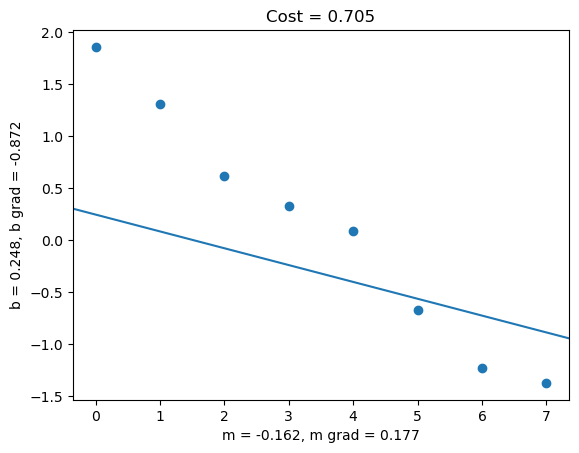

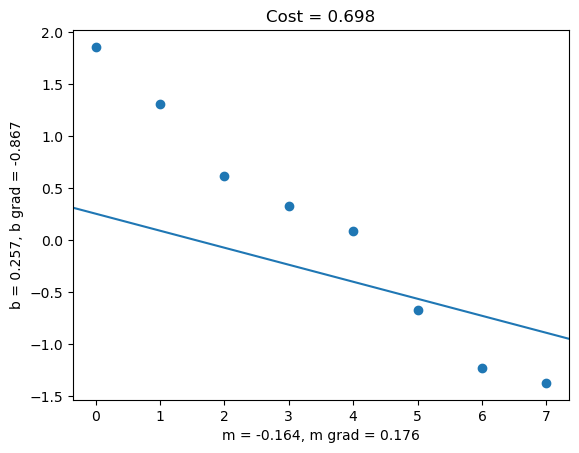

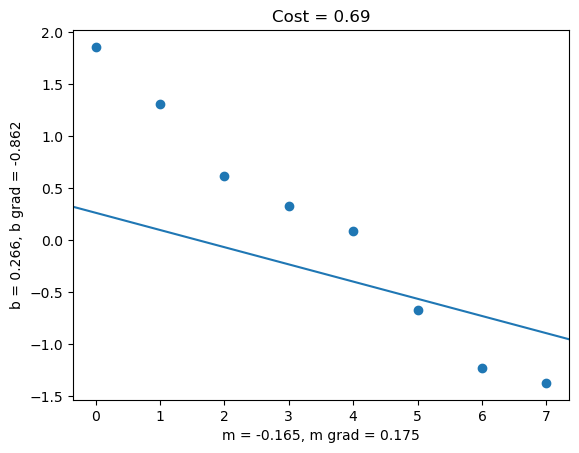

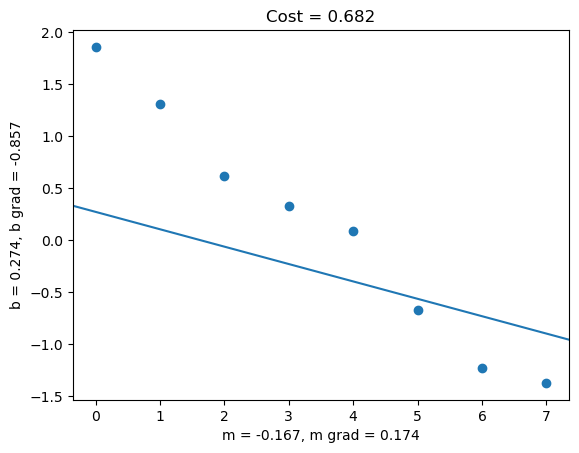

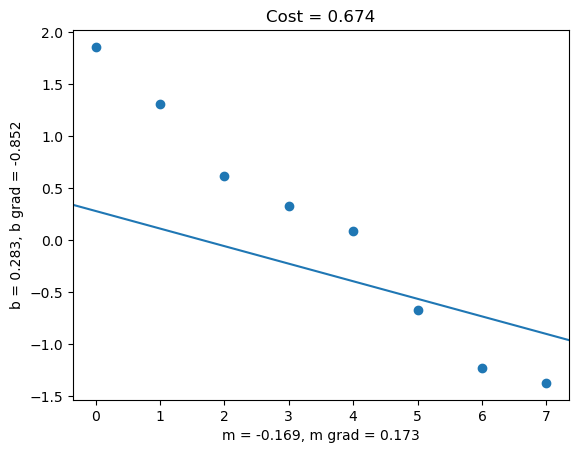

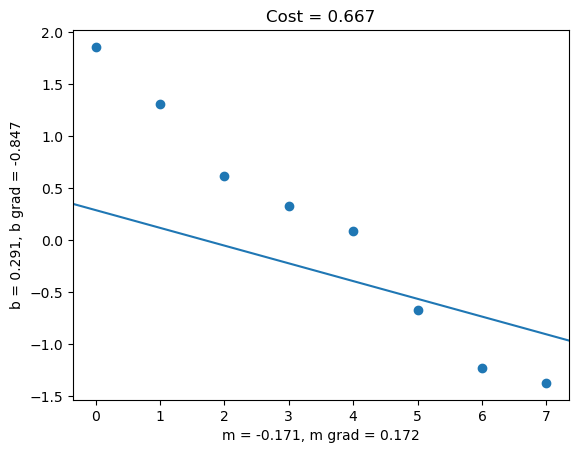

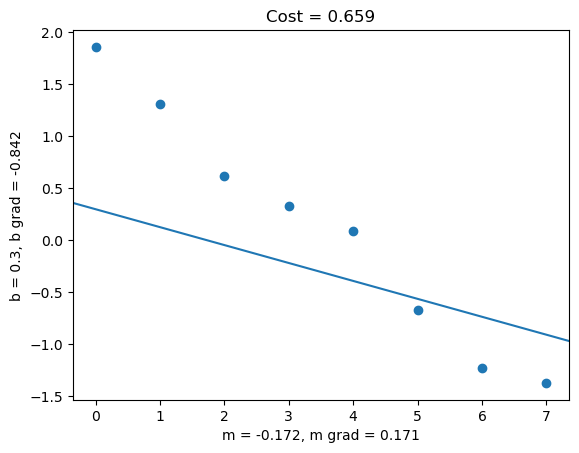

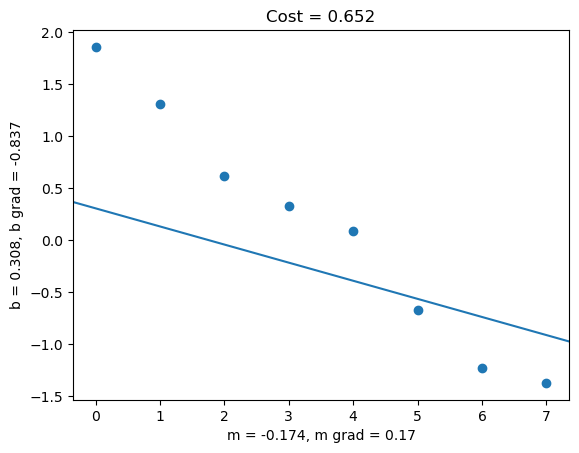

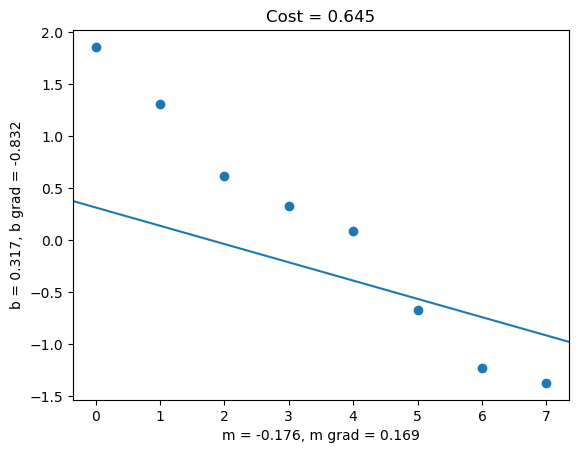

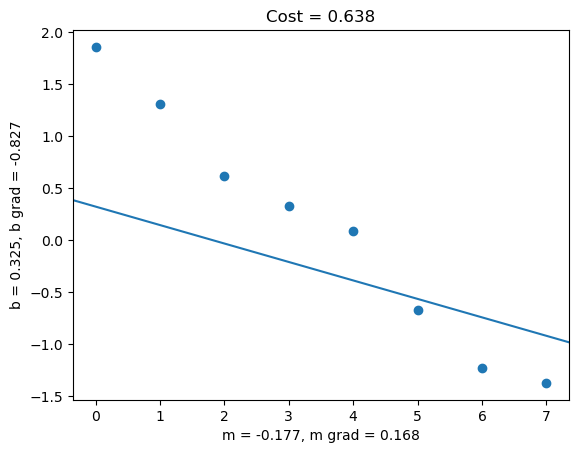

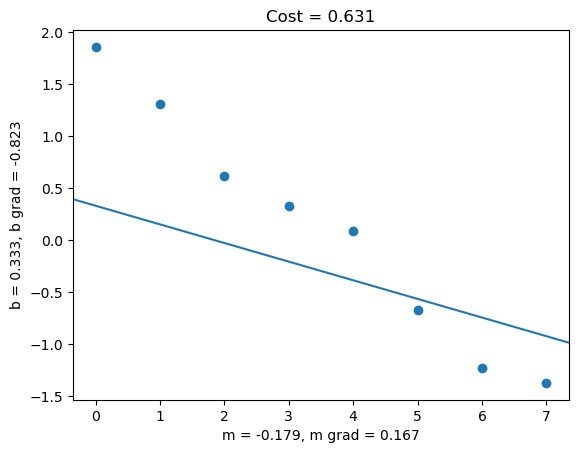

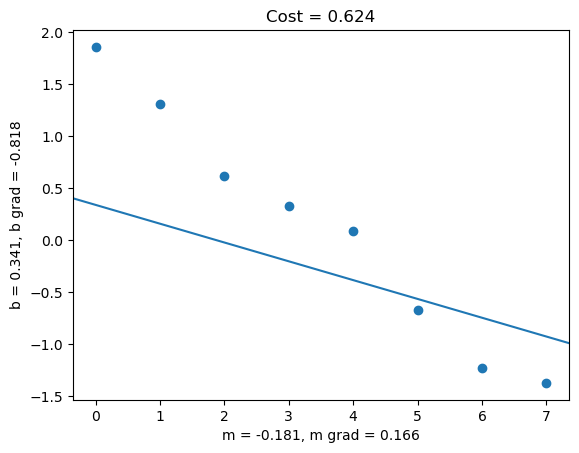

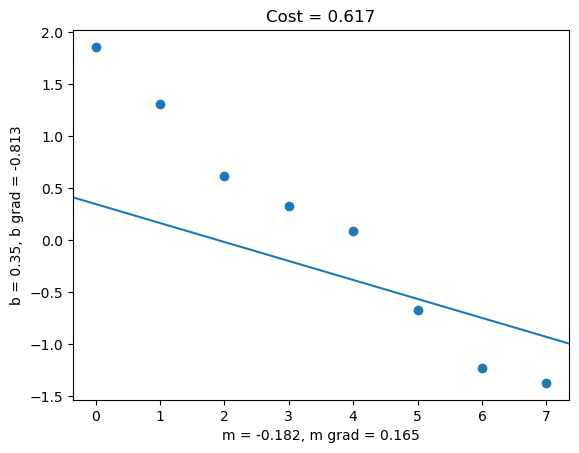

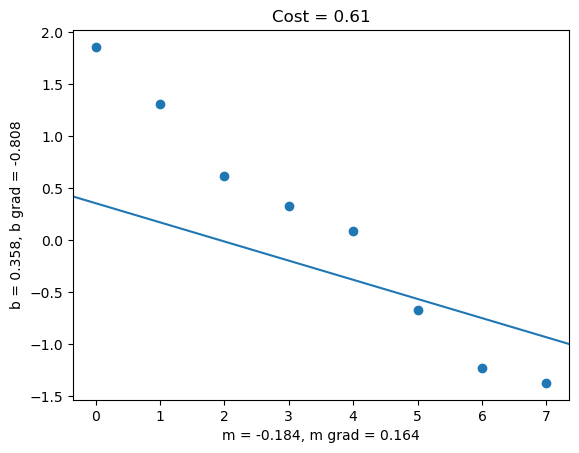

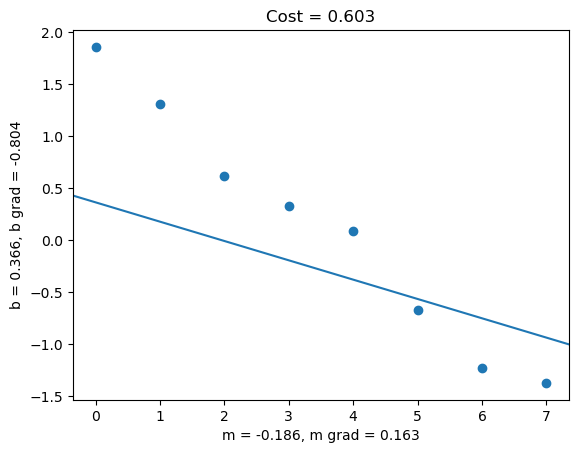

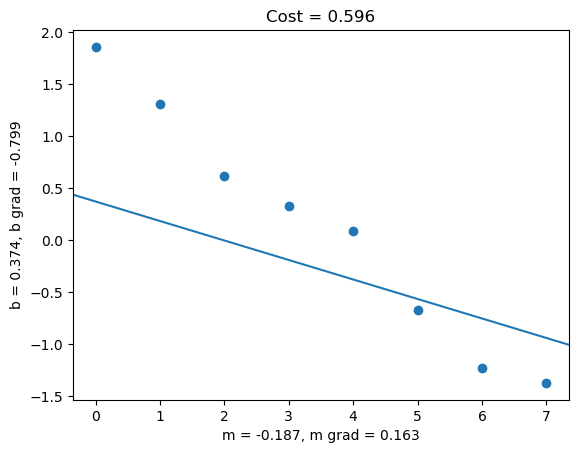

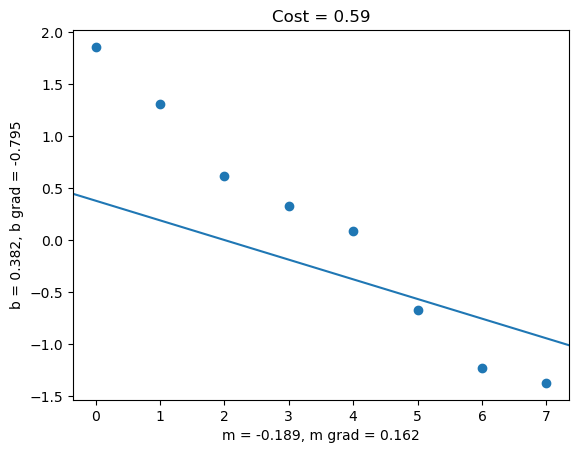

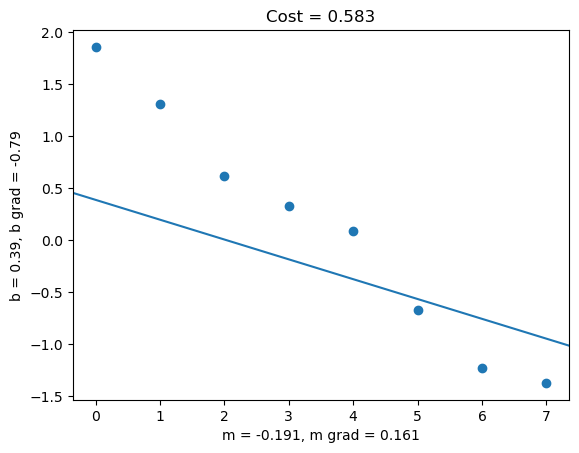

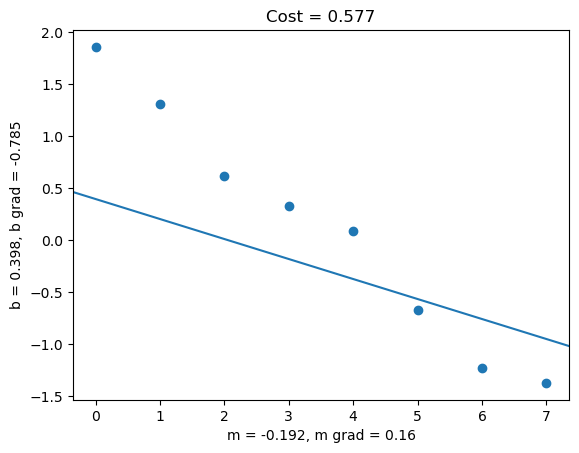

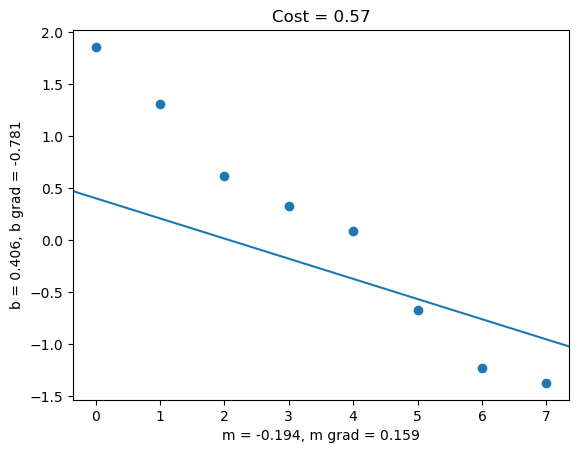

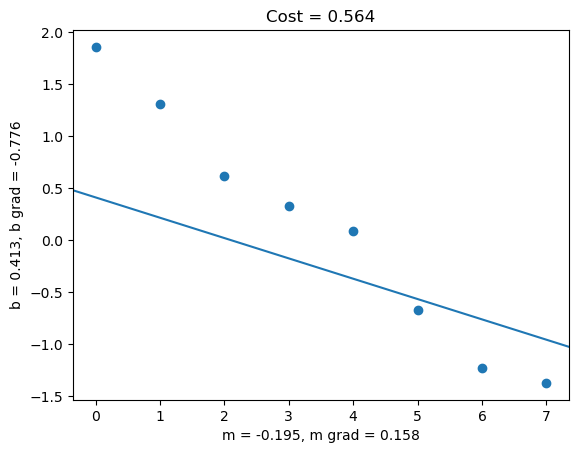

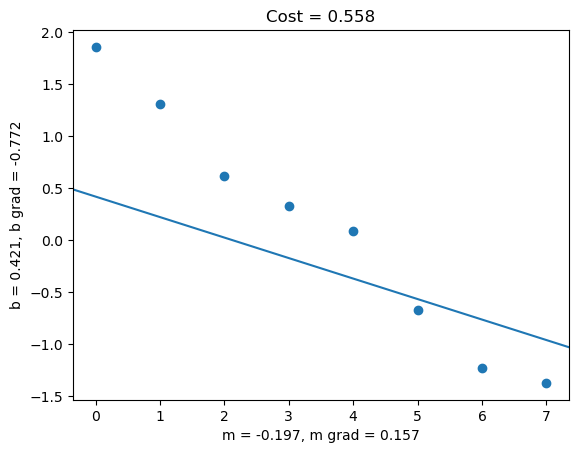

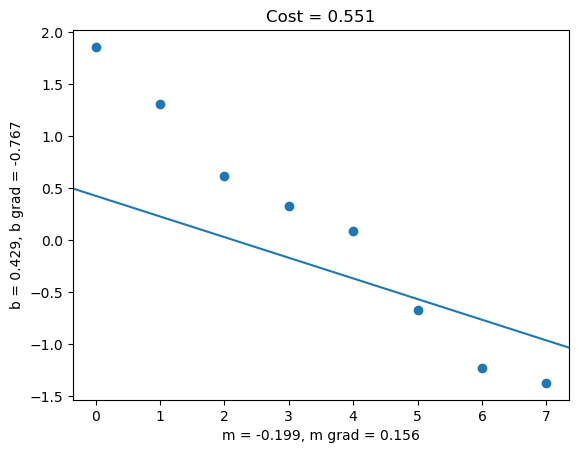

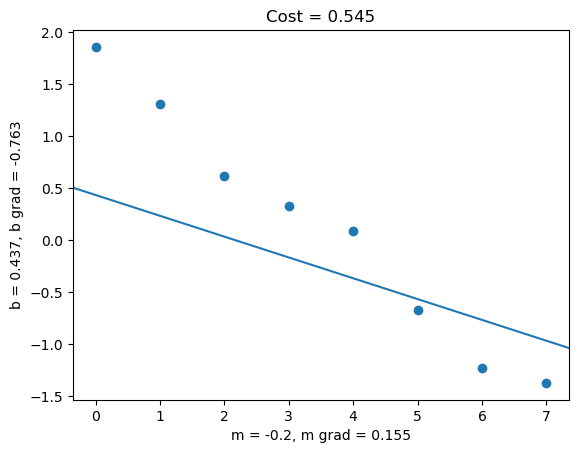

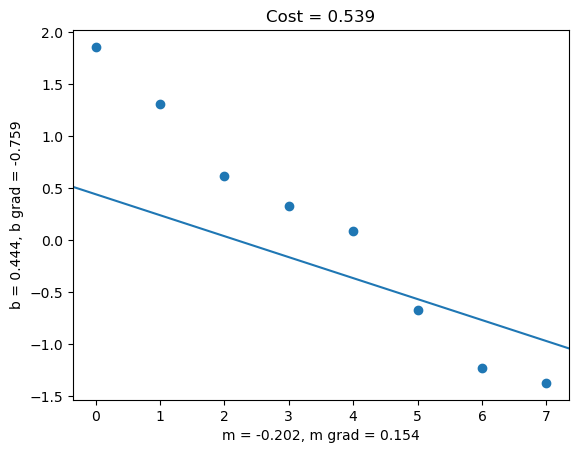

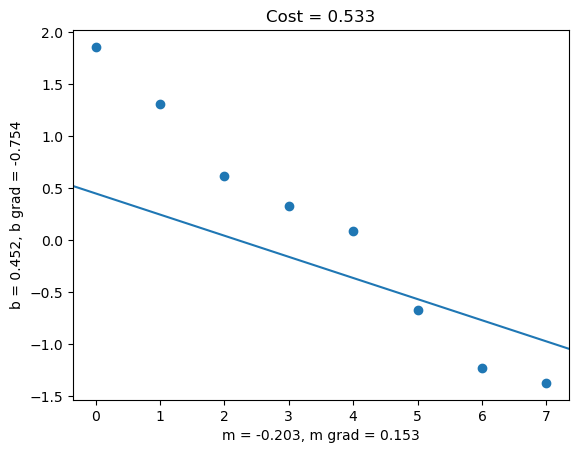

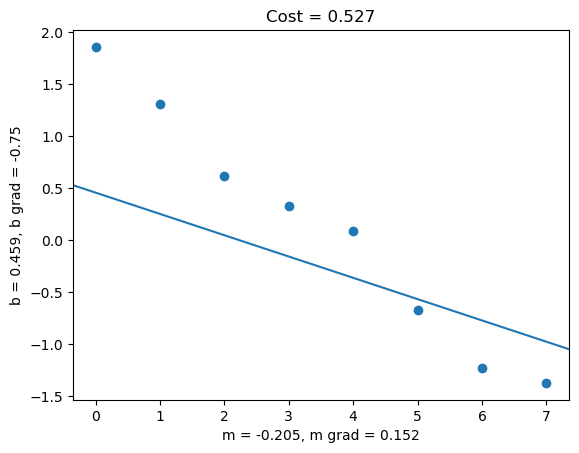

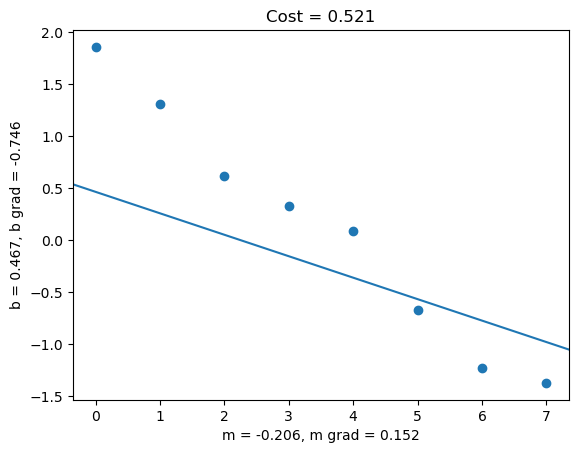

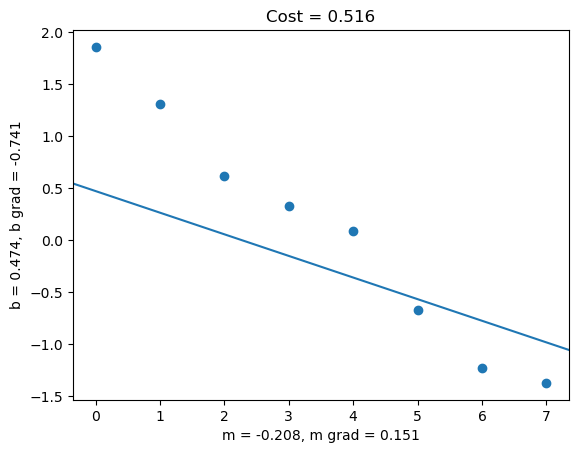

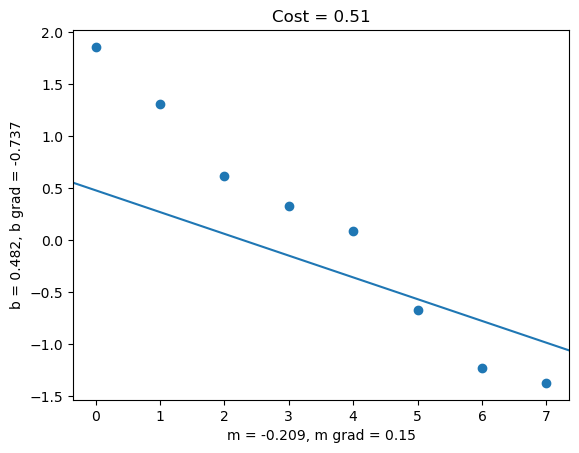

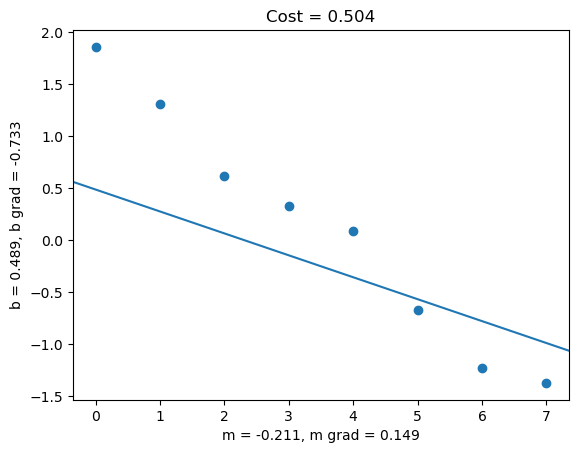

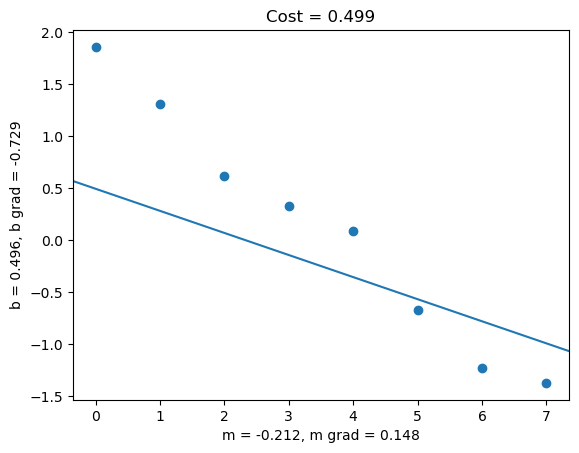

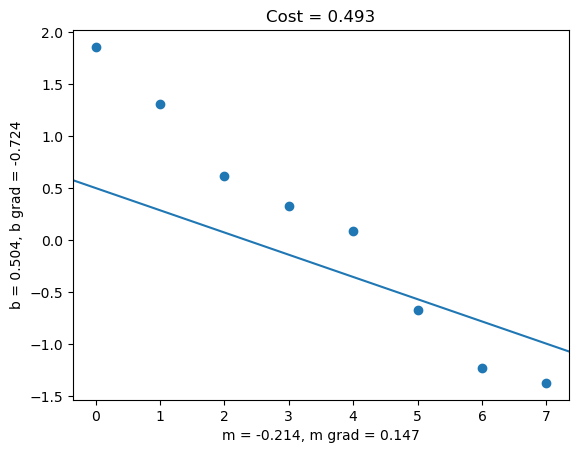

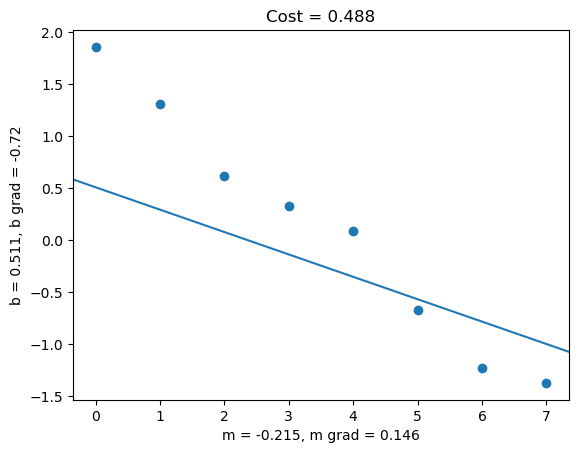

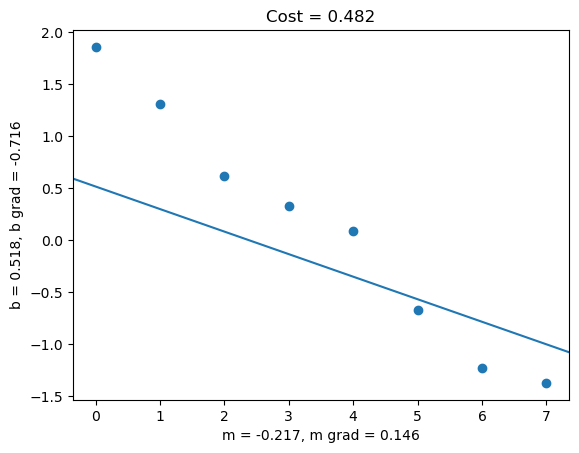

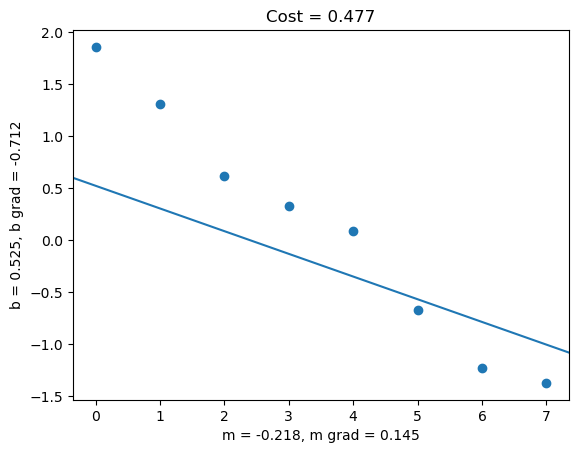

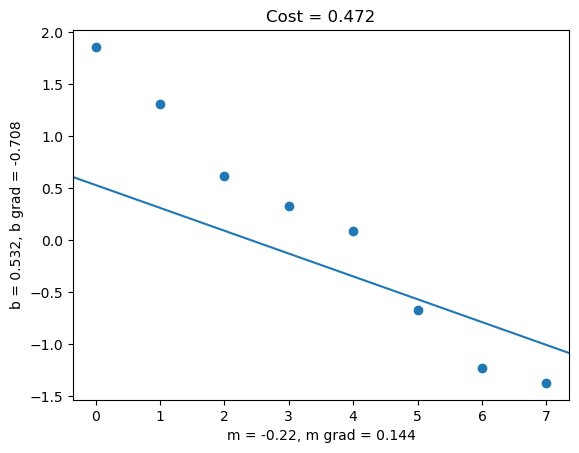

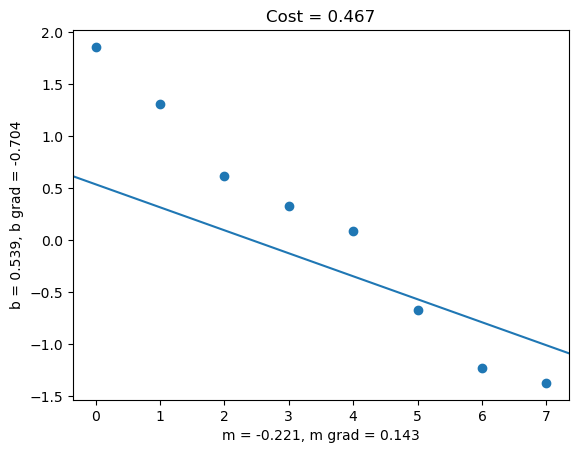

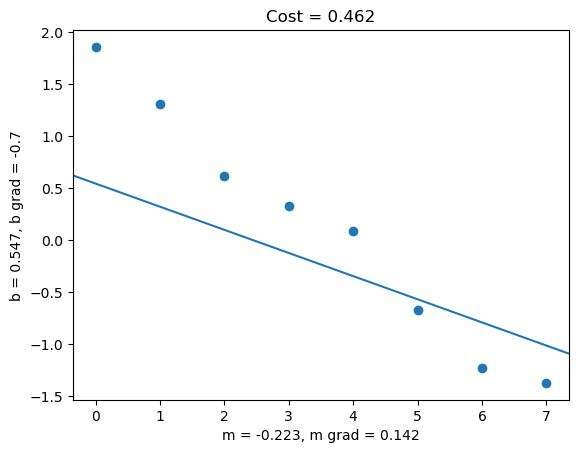

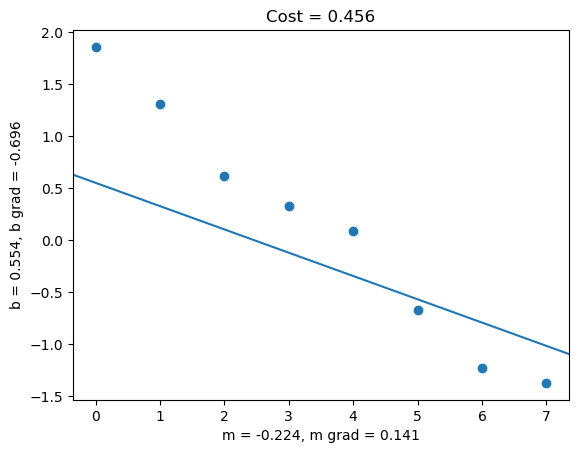

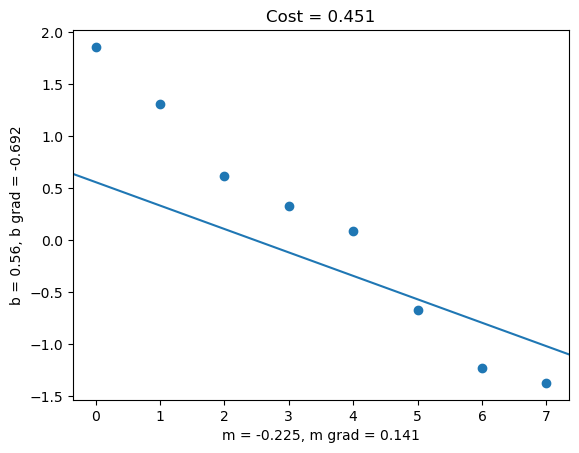

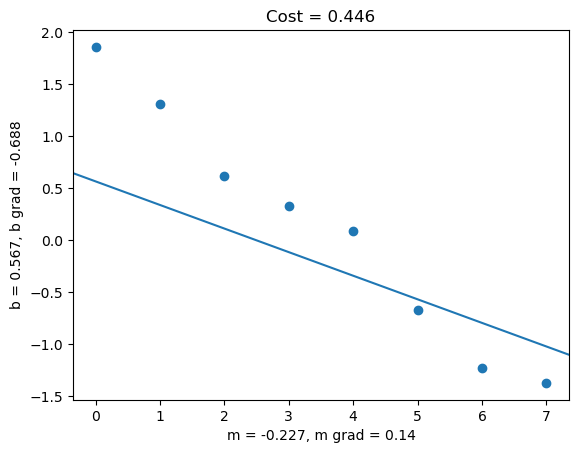

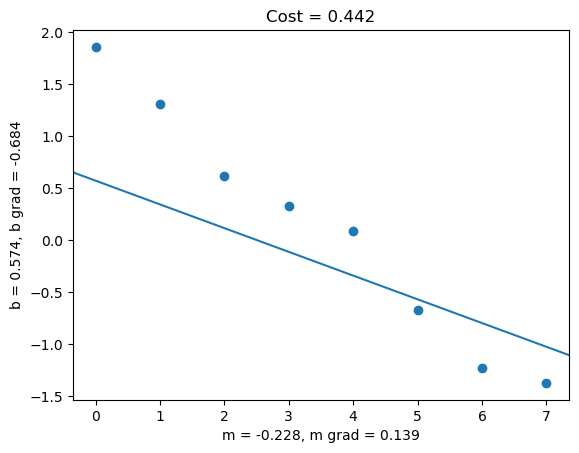

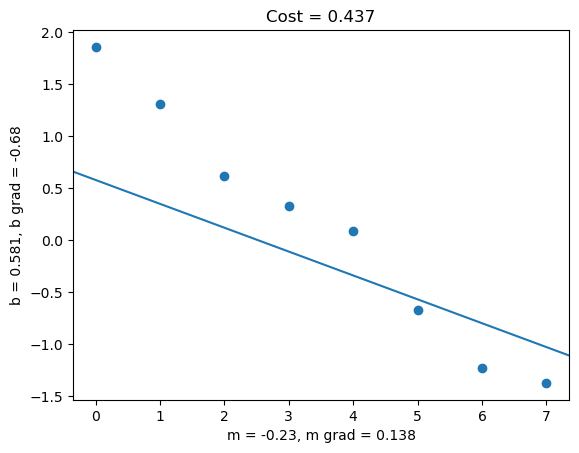

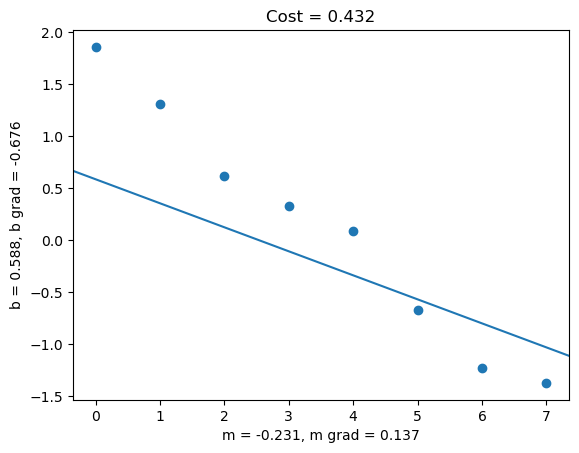

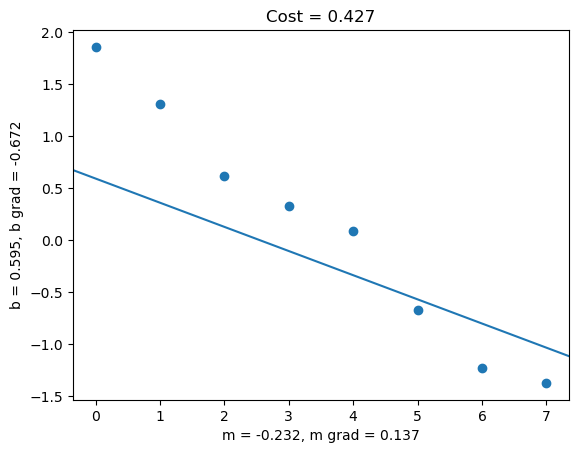

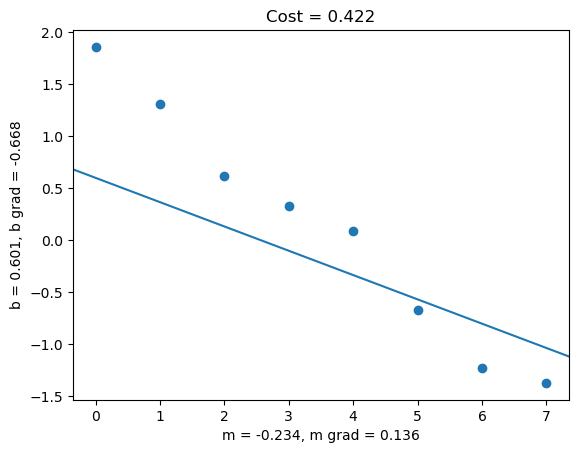

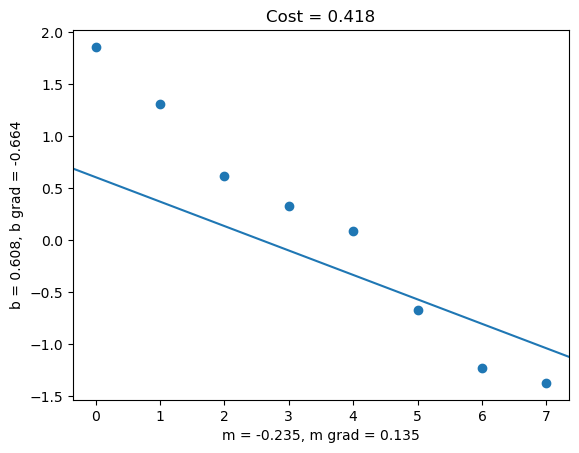

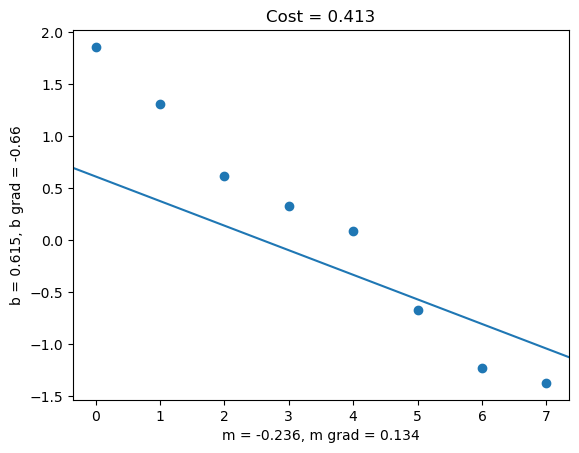

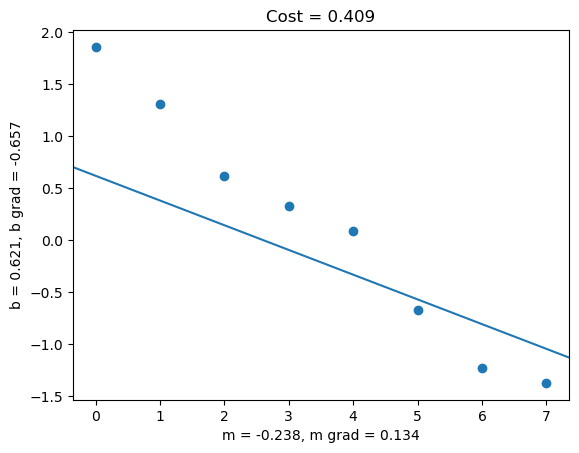

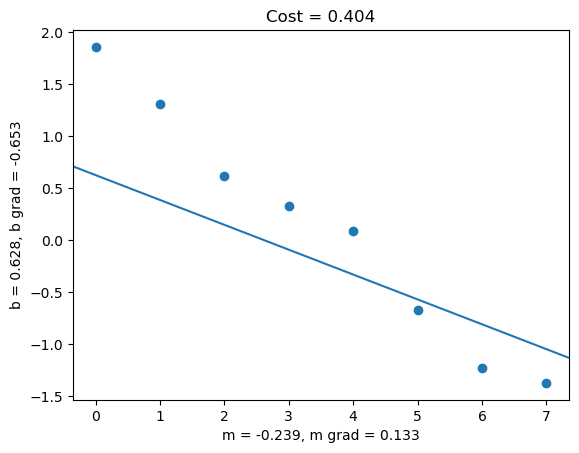

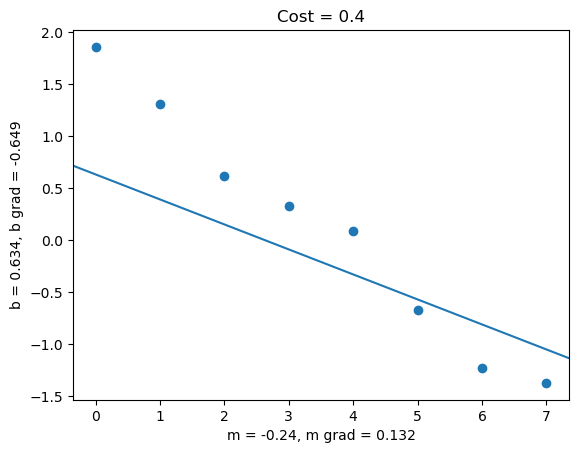

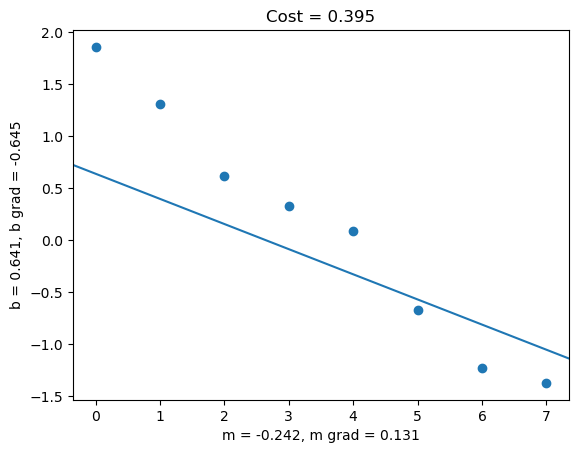

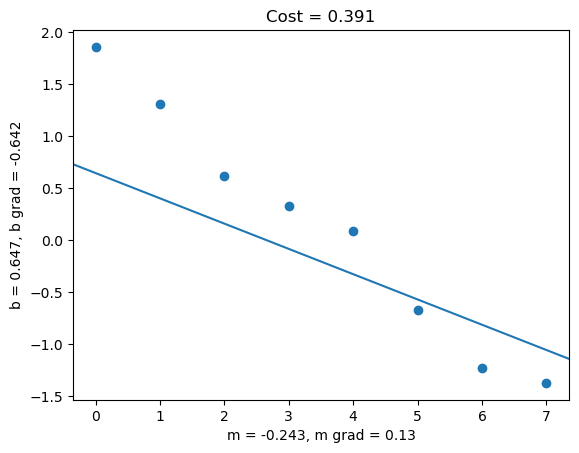

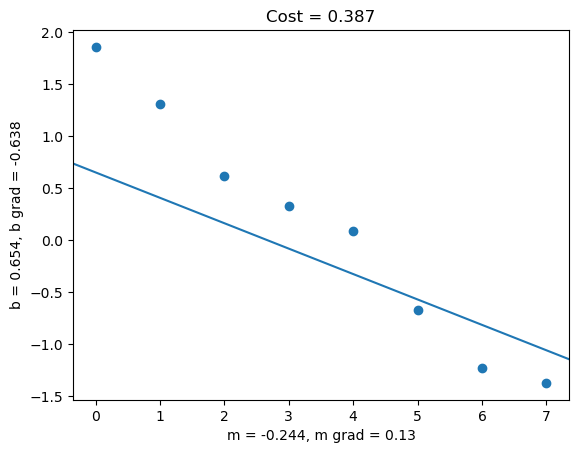

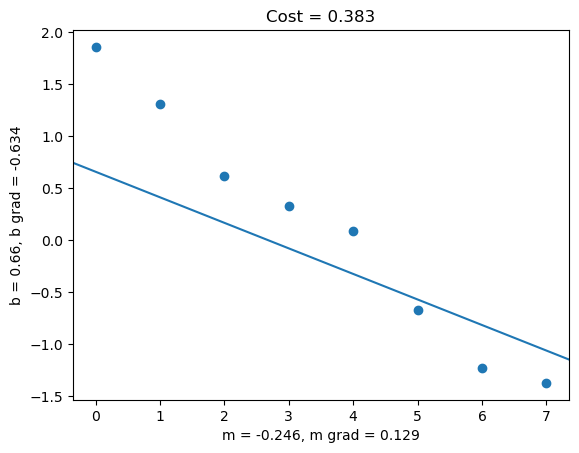

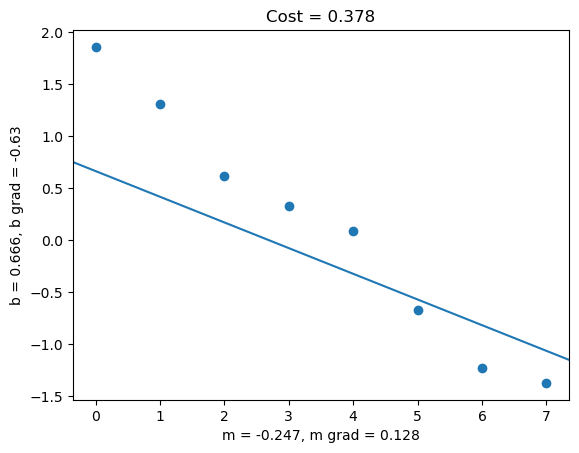

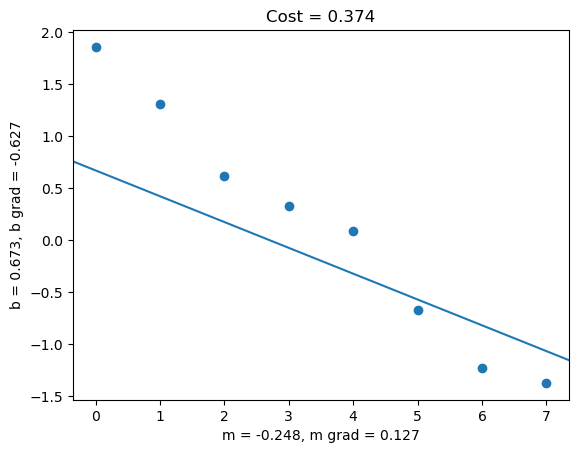

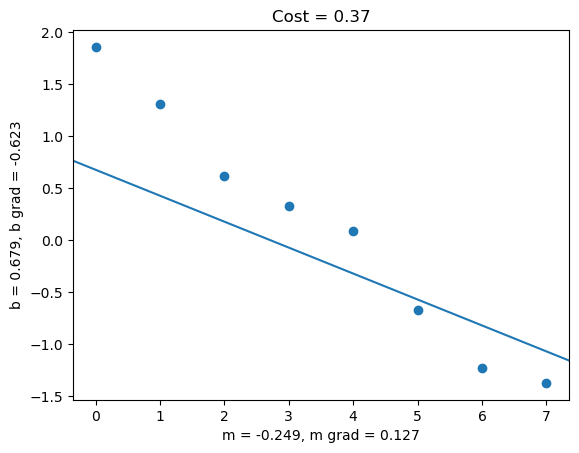

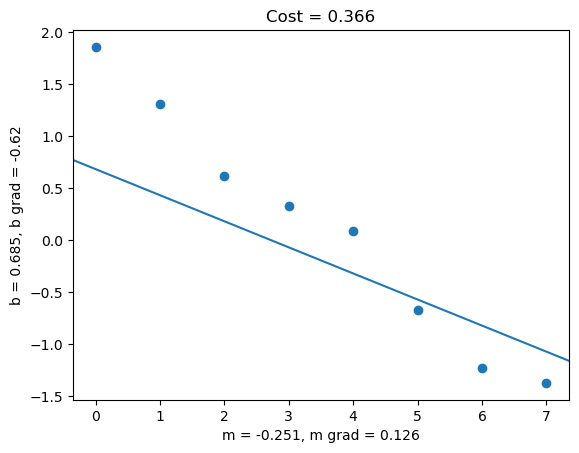

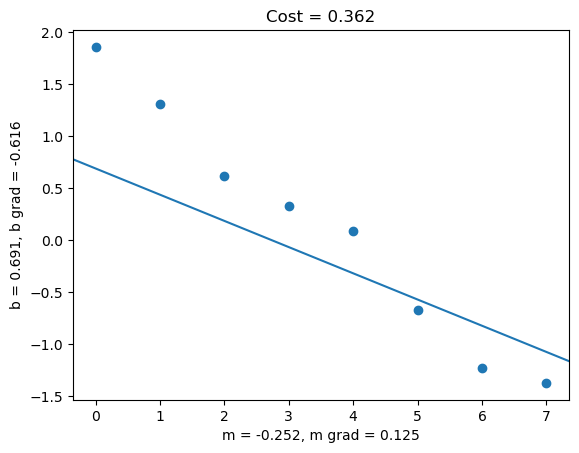

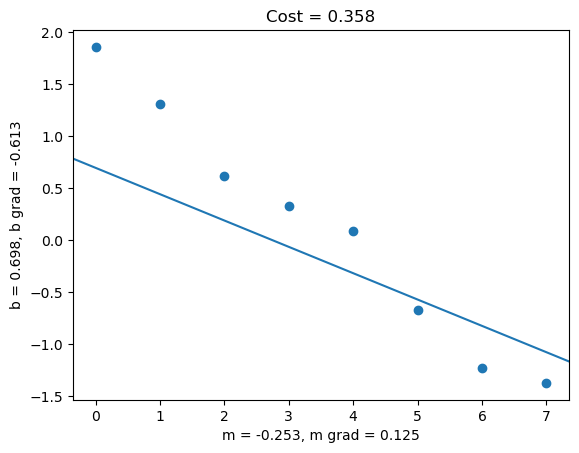

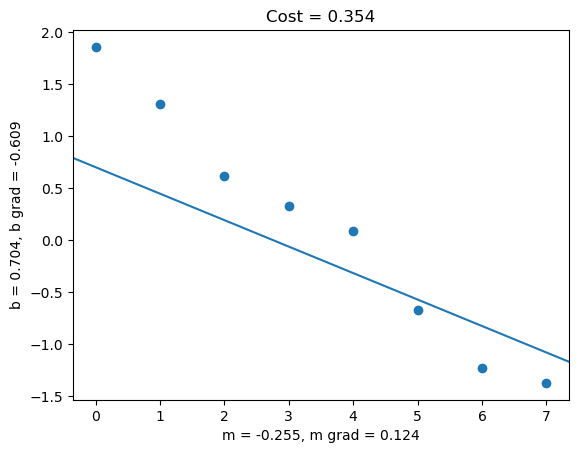

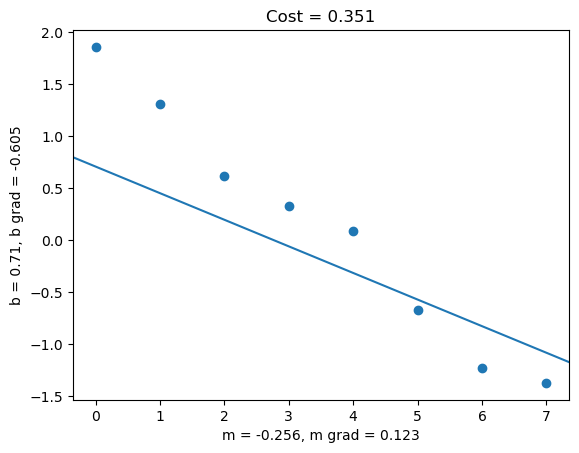

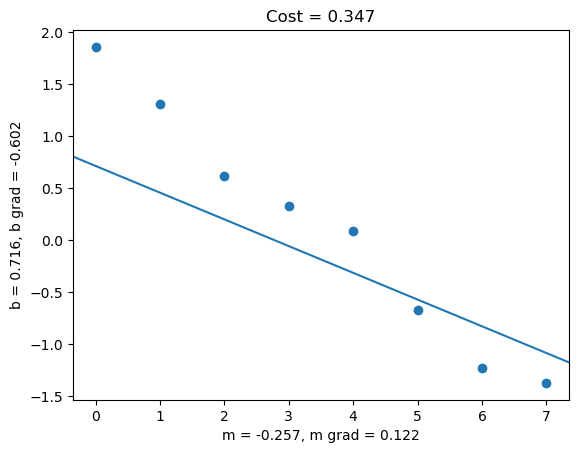

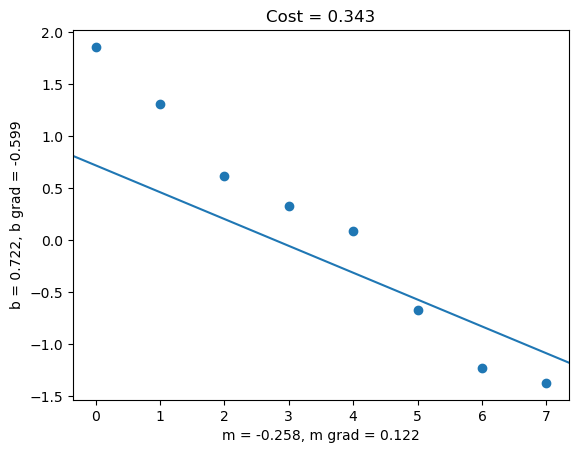

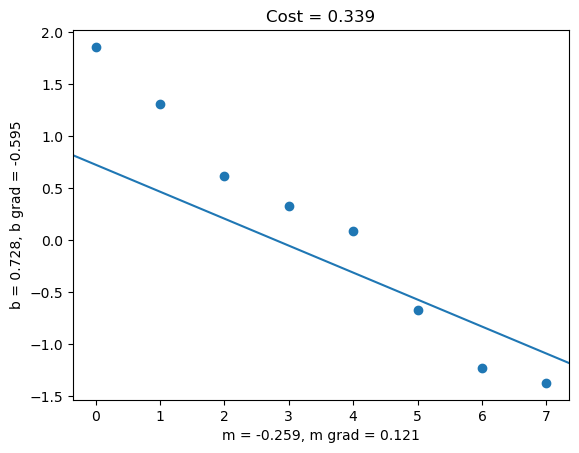

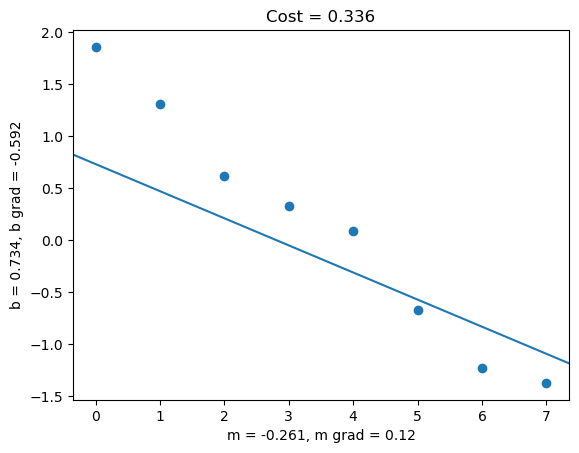

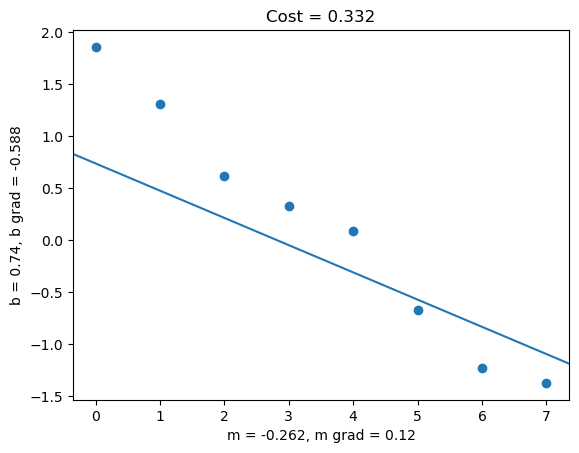

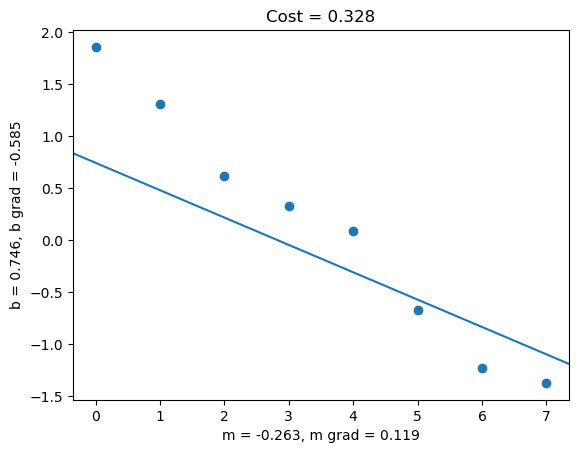

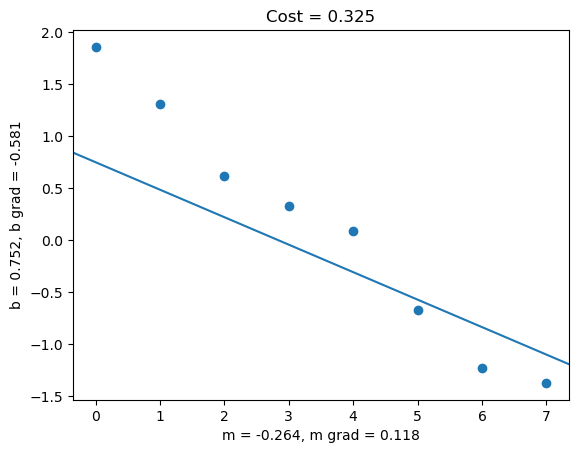

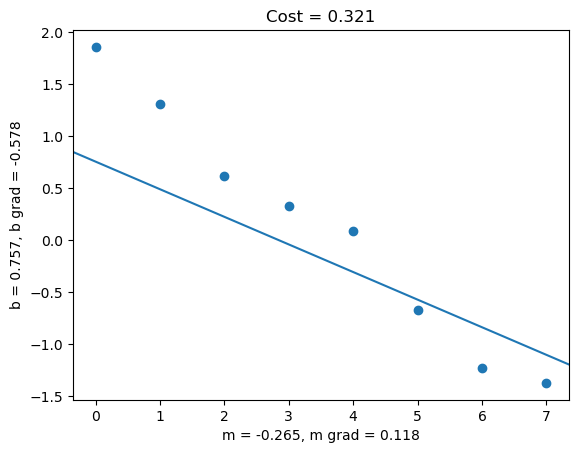

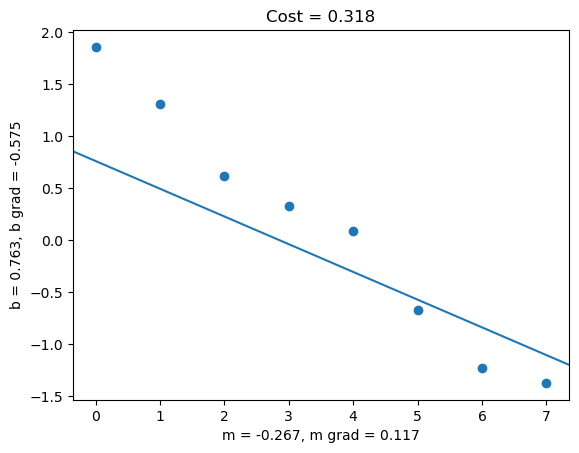

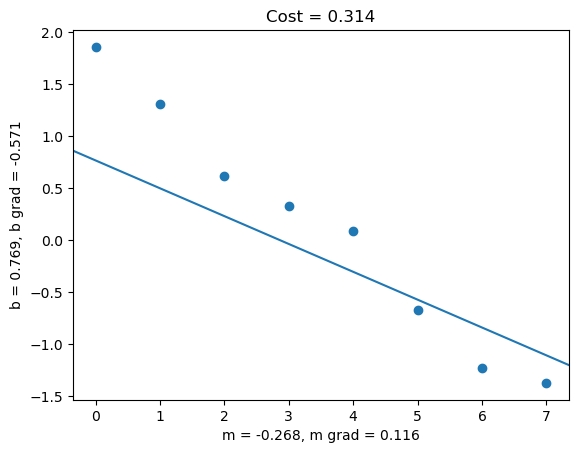

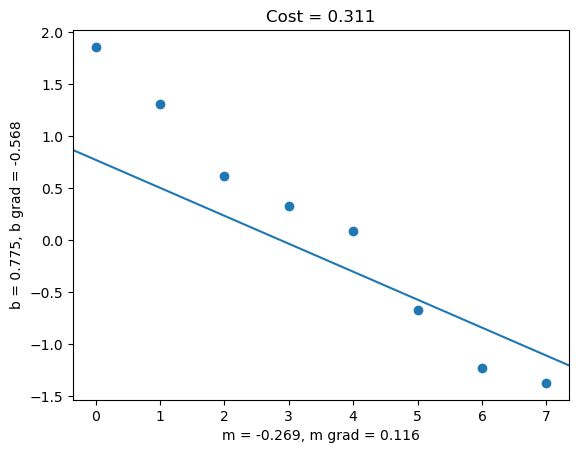

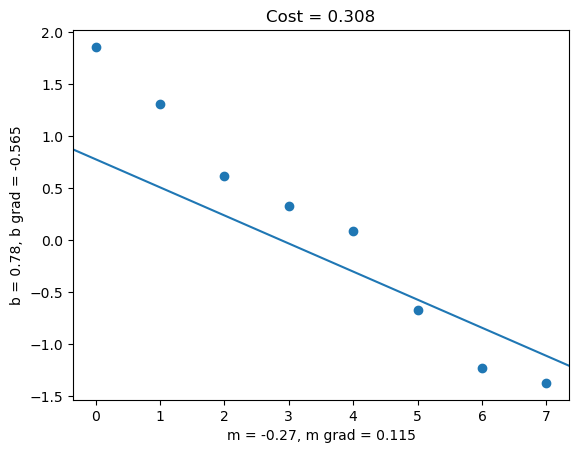

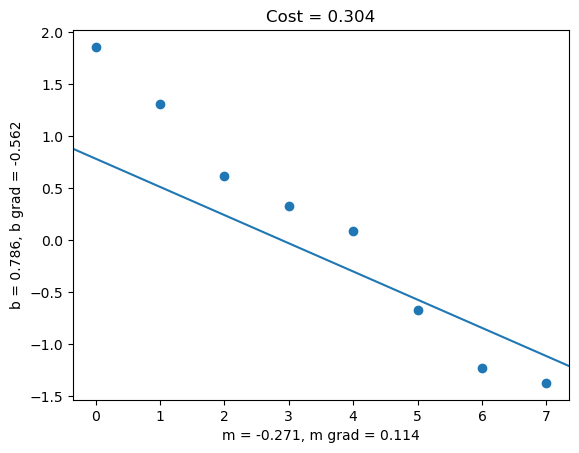

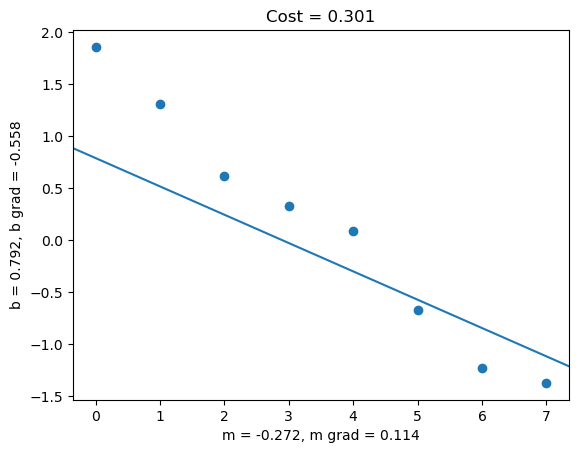

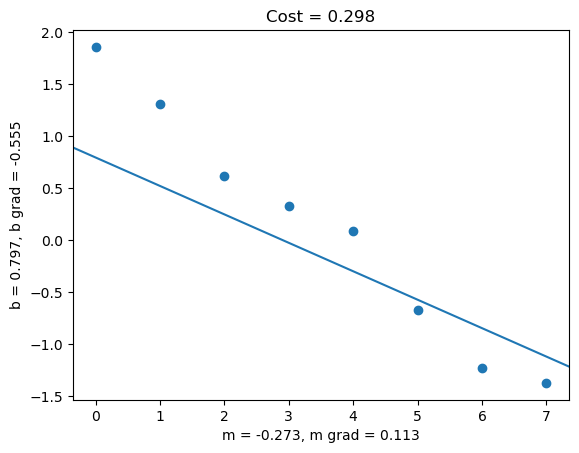

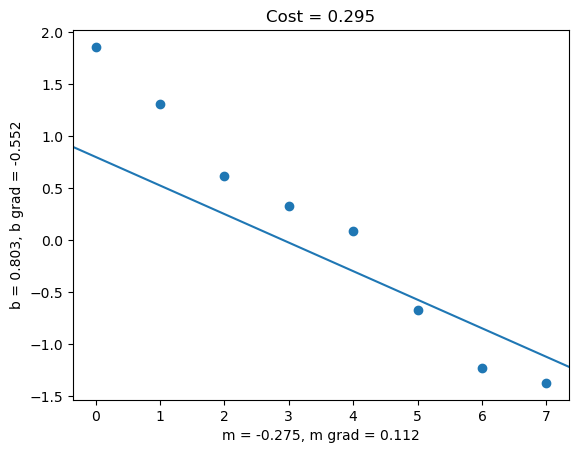

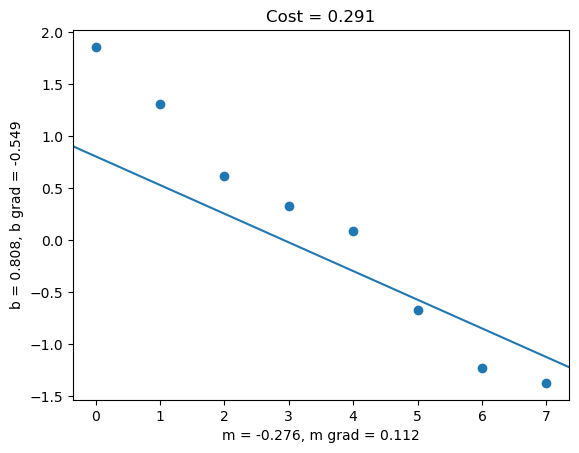

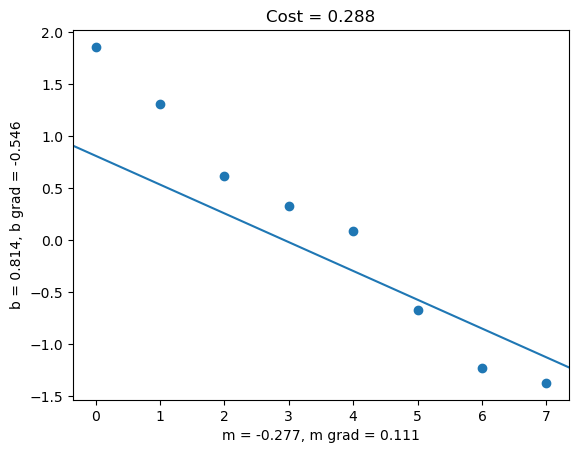

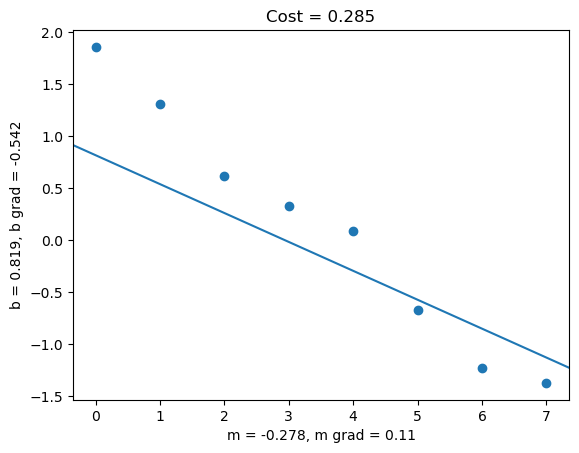

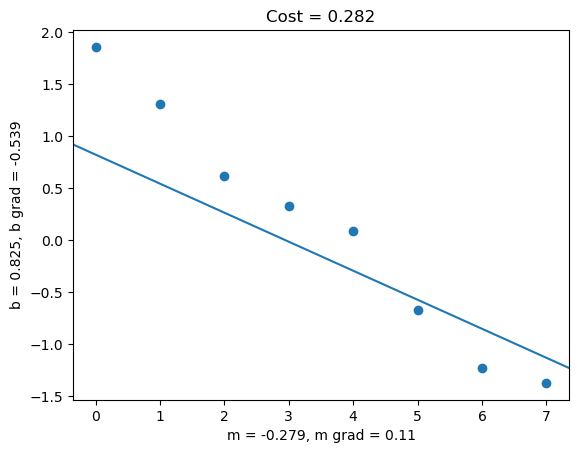

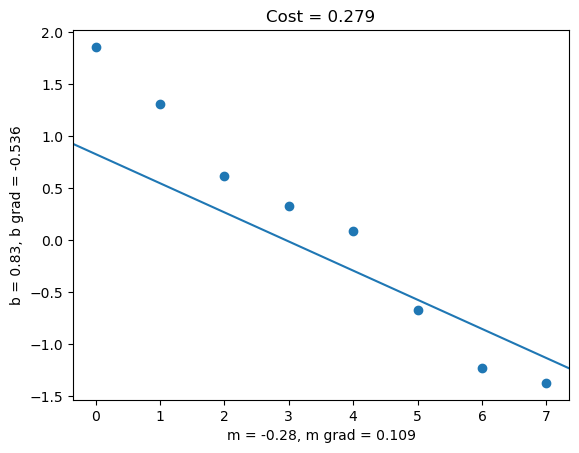

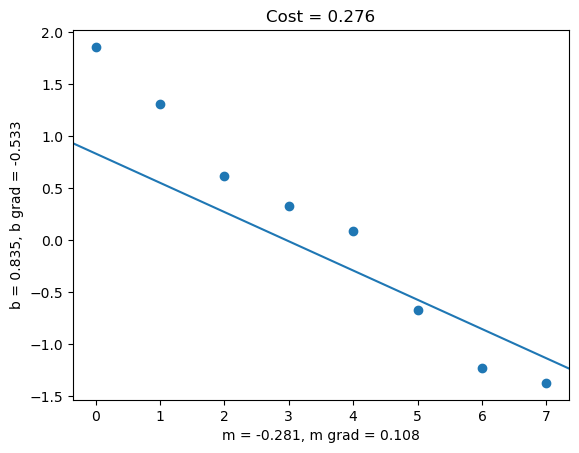

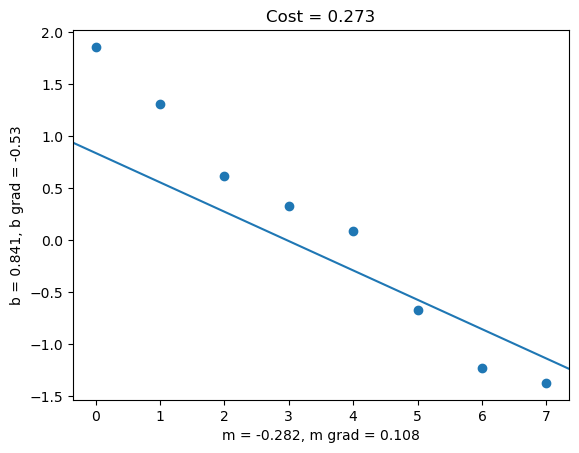

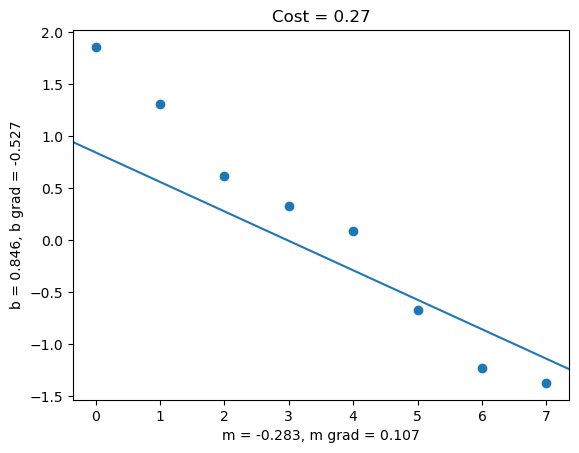

In [90]:
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()

    yhats = regression(xs,m,b)
    C = mse(yhats,ys)
    C.backward() #auto diff to calculate derivatives
    labeled_regression_plot(xs,ys,m,b,C)

    optimizer.step()